# BIRSVD evaluation

This notebook evaluates a fixed low-rank background model on
`../data/tutorial_evaluation.fits`, generated by
`generate_evaluation_data.ipynb`. Unlike the simpler tutorial demo, these
data include a time-varying additive base pattern, a time-varying flat-field
sensitivity pattern, and a nonlinear detector response (linearity curve),
as well as a moving source and counting noise.

BIRSVD approximates these variations using four shared spatial basis
images and frame-dependent coefficients. This tests the extent to which
a fixed linear subspace captures the changing background; the simulated
effects do not guarantee that the background is exactly rank four.

The results are written to `../data/evaluation_birsvd.fits`. The primary
HDU contains the residual cube, and `MODEL` contains the estimated
background. The mask and masked residual are displayed but are not saved
in this output file.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import astropy.io.fits as fits

from birsvd import birsvd
from birsvd import BIRSVDParameter

matplotlib.rcParams['image.origin'] = 'lower'
matplotlib.rcParams['legend.frameon'] = False

## Evaluation data

Load the data cube from the primary HDU and the source mask from the
`MASK` extension. Both have shape `(time, y, x)`. Mask values of 1 mark
pixels excluded from background fitting; values of 0 mark observed pixels.
The first plot displays the first six input frames.

The input file also contains the frame-dependent `FLAT` and `CONST`
cubes, before the nonlinear response and counting noise. This notebook
does not load or use these components in the fit. It fits the recorded
counts directly, without flat-field correction, inversion of the linearity
curve, or data standardization.

In [2]:
cube = fits.open('../data/tutorial_evaluation.fits')[0].data
mask = fits.open('../data/tutorial_evaluation.fits')['MASK'].data
nz, ny, nx = cube.shape

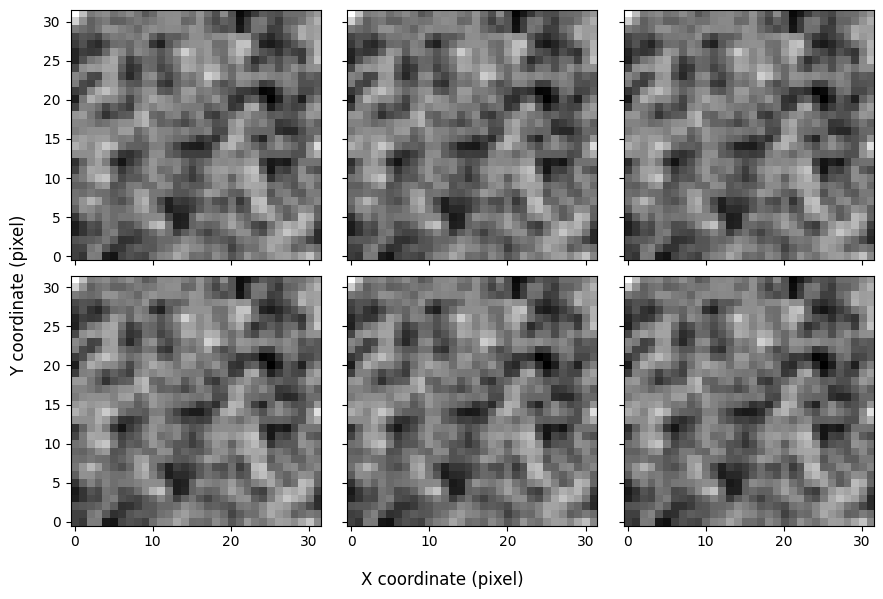

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
  ax.imshow(cube[n], cmap='gray')

fig.supxlabel('X coordinate (pixel)', fontsize=12)
fig.supylabel('Y coordinate (pixel)', fontsize=12)

fig.tight_layout()
plt.show()

### Inspect frame differences

Display `cube[10 * (n + 1)] - cube[10 * n]` for `n = 0, ..., 5`.
These differences between frames ten steps apart highlight background
changes and source motion. They are diagnostic plots only; the fit
uses the original data cube, not these differences.

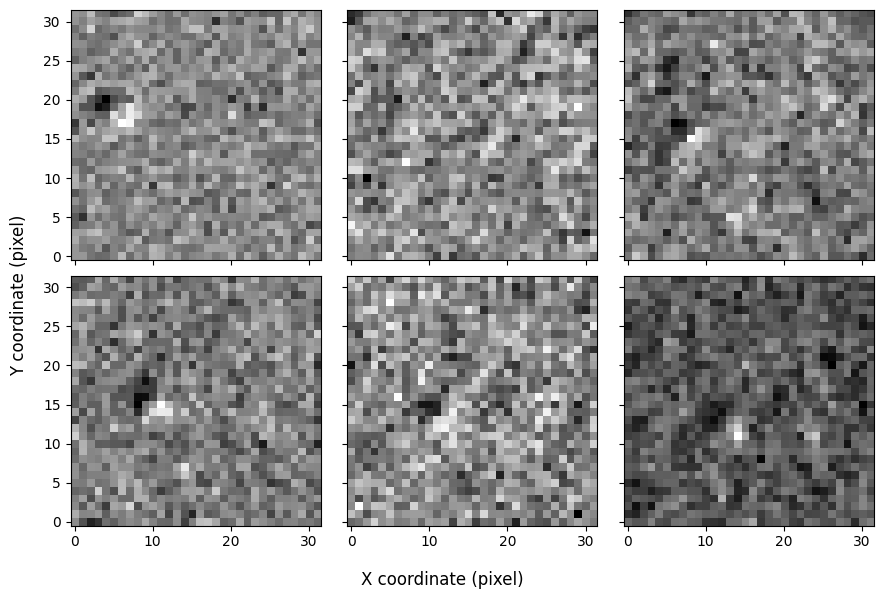

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
  ax.imshow(cube[10 * (n + 1)] - cube[10 * n], cmap='gray')

fig.supxlabel('X coordinate (pixel)', fontsize=12)
fig.supylabel('Y coordinate (pixel)', fontsize=12)

fig.tight_layout()
plt.show()

## Fit a rank-4 background with BIRSVD

Reshape the data cube to `(time, y * x)`, with one full detector frame per
row. Convert the fixed source mask to observation weights using
`weight = 1 - mask`, then reshape it in the same way. Excluded pixels
have zero weight in the data-fitting term; the mask is not updated.

Call `birsvd(data, weight, n_rank, param=param)` with `n_rank = 4` to
jointly estimate four spatial basis images and their frame-wise
coefficients. The routine alternates regularized weighted least-squares
updates of the left and right factors using iterative LSQR solves.

`BIRSVDParameter` explicitly sets `n_iter=50`, `r_degree_L=1e-4`, and
`r_degree_R=1e-4`. In this implementation, `n_iter` controls both the
outer iterations and the LSQR iteration count for each factor update.
The regularization strengths apply to the temporal and flattened-pixel
factors, respectively. Initialization and regularization types use the
library defaults; this notebook does not set a random seed.

`result.A` reconstructs the background as `U @ diag(S) @ V.T`, including
the masked pixels. `result.residual(data)` returns `data - result.A`.

In [5]:
data = cube.reshape(nz, ny * nx)
weight = (1.0 - mask).reshape(nz, ny * nx)
n_rank = 4

param = BIRSVDParameter(
  n_iter=50,
  r_degree_L=0.0001,
  r_degree_R=0.0001,
)

result = birsvd(data, weight, n_rank, param=param)
res = result.residual(data)

## Inspect the reconstructed background and source

Restore the matrix outputs to `(time, y, x)` and inspect frame 20.
Compare the input counts with the estimated background, residual, and
fixed mask. `sparse = mask * residual` retains residual values only in
the masked source region; it is not a separately optimized component.

Residuals can contain counting noise and background-model mismatch as
well as the source. The detector response is not inverted, so the
residual is not a recovery of the source's pre-response intensity.

The panel labelled `uncertainty` currently repeats the input frame as a
placeholder. This notebook does not compute an uncertainty estimate.

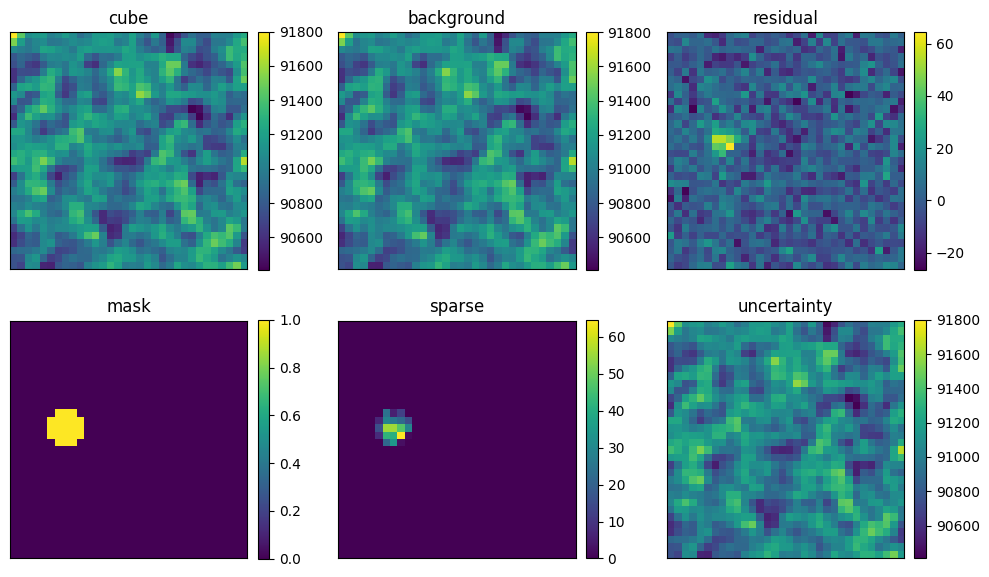

In [6]:
frame_index = 20
background = result.A.reshape(nz, ny, nx)
residual = res.reshape(nz, ny, nx)
maskcube = mask.reshape(nz, ny, nx)
sparse = maskcube * residual

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
items = [
  ('cube', cube[frame_index]),
  ('background', background[frame_index]),
  ('residual', residual[frame_index]),
  ('mask', maskcube[frame_index]),
  ('sparse', sparse[frame_index]),
  ('uncertainty', cube[frame_index]),
]

for axis, (title, image) in zip(axes.ravel(), items):
  handle = axis.imshow(image, origin='lower', cmap='viridis')
  axis.set_title(title)
  axis.set_xticks([])
  axis.set_yticks([])
  fig.colorbar(handle, ax=axis, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

In [7]:
hdul = fits.HDUList([
  fits.PrimaryHDU(data=residual),
  fits.ImageHDU(data=background, name='MODEL'),
])
hdul.writeto('../data/evaluation_BIRSVD.fits', overwrite=True)

## Inspect the spatial basis images

Reshape the four columns of `result.V` to detector images and display
them in a 2 x 2 grid. These spatial basis vectors are shared across all
frames; their frame-wise amplitudes are the corresponding columns of
`U` multiplied by the singular values `S`.

The fitted vectors describe the recorded background collectively. They
need not correspond individually to the physical base, flat, or detector
response, and are not the `CONST` or `FLAT` cubes saved by the generator.

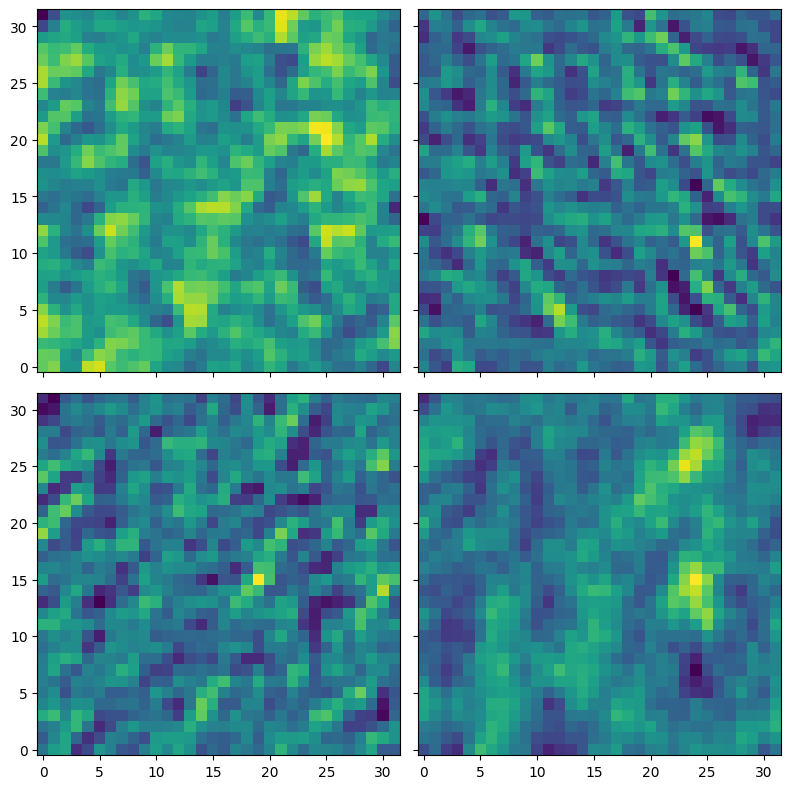

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)

axes[0, 0].imshow(result.V[:, 0].reshape(ny, nx))
axes[0, 1].imshow(result.V[:, 1].reshape(ny, nx))
axes[1, 0].imshow(result.V[:, 2].reshape(ny, nx))
axes[1, 1].imshow(result.V[:, 3].reshape(ny, nx))

fig.tight_layout()
plt.show()